# Project 10 — Habitable-zone target selection (PLATO-style pipeline)

This notebook follows **Project 10** tasks: synthetic light curves (stand-in for **PlatoSim / PLATOnium** outputs), **BLS** transit recovery, physical habitability indicators ($L_*/L_\odot$, $S$ in Earth units, $T_\mathrm{eq}$), habitable-zone screening, and a transparent **ranking score**.

**Important:** Production work should use the official workflow (`picsim` → `varsim` → `payload` → `platonium`) and replace the synthetic generator with your exported time series from PlatoSim.

In [21]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import habitable_zone_pipeline as hz

In [22]:
systems = hz.default_sample_systems()
inj, results = hz.analyze_systems(systems=systems, seed=42)
inj, results

(                system    star planet  P_injected_d   a_AU  Rp_Rearth  Teff_K  \
 0        HZ_earth_like    HZ-A      b         289.0  1.020        1.1  5780.0   
 1  hot_jupiter_control   Hot-A      b           3.5  0.045       11.0  6000.0   
 2      cold_subneptune  Cold-A      b         420.0  1.150        3.2  5200.0   
 3       HZ_super_earth    HZ-B      b         198.0  0.680        1.6  5600.0   
 4             HZ_noisy    HZ-C      b         240.0  0.780        1.3  5750.0   
 
    Rstar_Rsun  noise_mult  
 0        1.00         1.0  
 1        1.05         1.0  
 2        0.85         1.0  
 3        0.92         1.0  
 4        1.00         3.5  ,
                 system    star planet  P_injected_d  P_recovered_d    L_Lsun  \
 0        HZ_earth_like    HZ-A      b         289.0     435.480640  1.005556   
 1  hot_jupiter_control   Hot-A      b           3.5       3.500088  1.287296   
 2      cold_subneptune  Cold-A      b         420.0     420.066033  0.475933   
 3     

## Example synthetic light curve (suggested plot: PLATO-like photometry)

Replace `generate_synthetic_plato_like_lightcurve` with loading PlatoSim products when available.

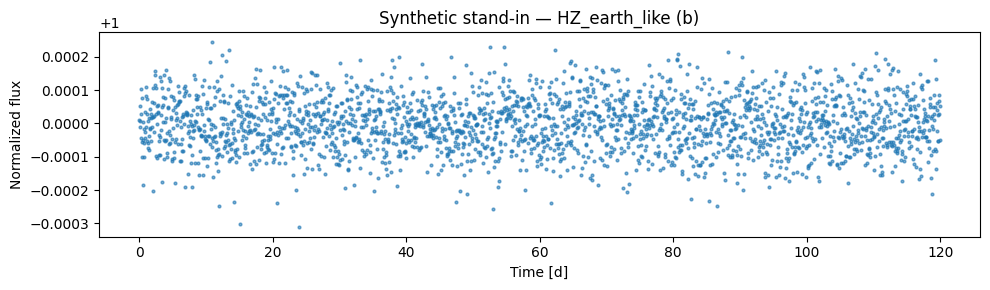

In [23]:
sys0 = systems[0]
p0 = sys0.planets[0]
time = np.arange(0.0, 120.0, 0.05)
t, f = hz.generate_synthetic_plato_like_lightcurve(
    time,
    p0.period_days,
    t0_days=2.0,
    rp_earth=p0.radius_earth,
    r_star_solar=sys0.star.radius_solar,
    noise_ppm=80.0,
    seed=0,
)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, f, "o", ms=2, alpha=0.6)
ax.set_xlabel("Time [d]")
ax.set_ylabel("Normalized flux")
ax.set_title(f"Synthetic stand-in — {sys0.label} ({p0.name})")
plt.tight_layout()
plt.show()

## Injected vs recovered period (BLS)

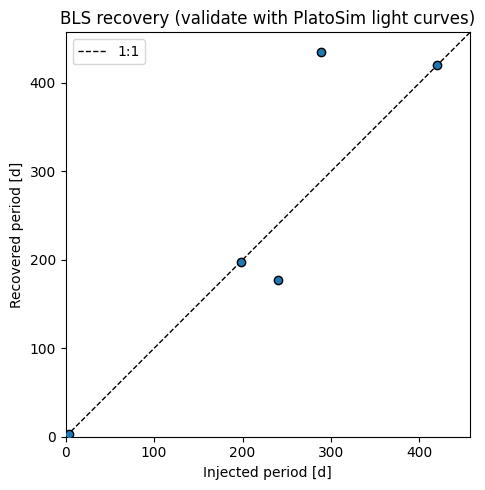

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(results["P_injected_d"], results["P_recovered_d"], c="C0", ec="k", zorder=3)
lims = [0, max(results["P_injected_d"].max(), results["P_recovered_d"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Injected period [d]")
ax.set_ylabel("Recovered period [d]")
ax.legend()
ax.set_title("BLS recovery (validate with PlatoSim light curves)")
plt.tight_layout()
plt.show()

## Incident flux $S$ (Earth units) vs planet radius

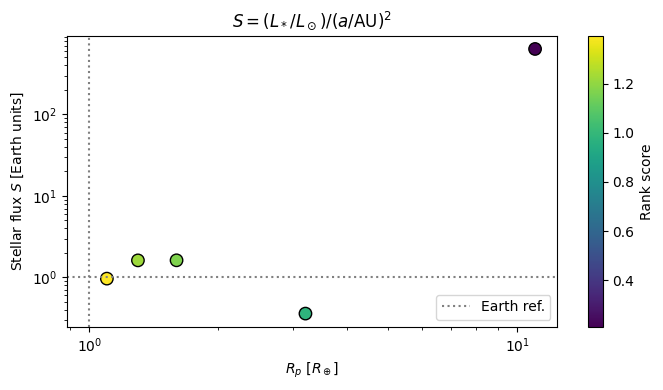

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(
    inj["Rp_Rearth"],
    results["S_earth"],
    c=results["rank_score"],
    cmap="viridis",
    s=80,
    ec="k",
)
plt.colorbar(sc, ax=ax, label="Rank score")
ax.axvline(1.0, color="0.5", ls=":")
ax.axhline(1.0, color="0.5", ls=":", label="Earth ref.")
ax.set_xlabel(r"$R_p$ [$R_\oplus$]")
ax.set_ylabel(r"Stellar flux $S$ [Earth units]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title(r"$S = (L_*/L_\odot)/(a/\mathrm{AU})^2$")
plt.tight_layout()
plt.show()

## Histogram of equilibrium temperatures

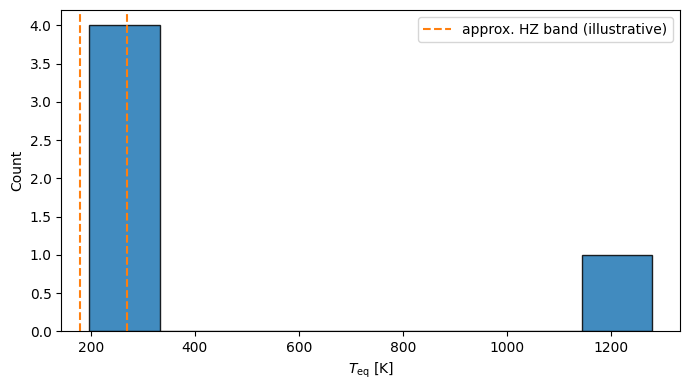

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(results["Teq_K"], bins=8, color="C0", edgecolor="k", alpha=0.85)
ax.axvline(180, color="C1", ls="--", label="approx. HZ band (illustrative)")
ax.axvline(270, color="C1", ls="--")
ax.set_xlabel(r"$T_\mathrm{eq}$ [K]")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## Top-ranked targets (bar chart)

Score: $H_\mathrm{HZ} + 0.2 H_{R_p} + 0.15 H_\mathrm{host} + 0.15 H_\mathrm{det} + 0.1 H_\mathrm{stab}$ (see course document).

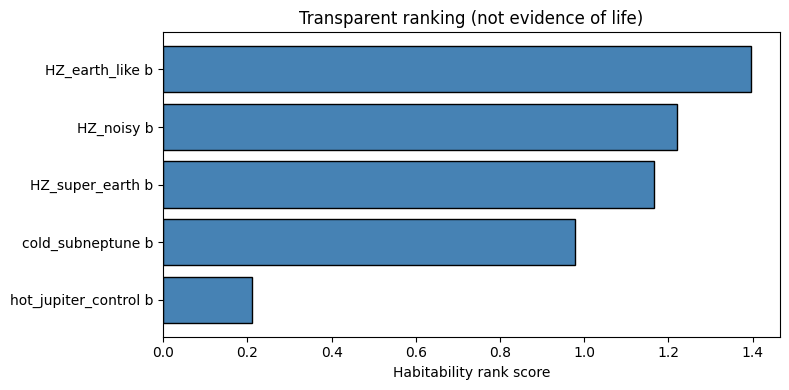

,system,planet,S_earth,Teq_K,in_habitable_zone_flux,rank_score
0,HZ_earth_like,b,0.966509,252.426857,True,1.395480
1,HZ_noisy,b,1.618739,287.162914,False,1.221697
2,HZ_super_earth,b,1.621827,287.299779,False,1.164914
3,cold_subneptune,b,0.359874,197.184010,False,0.978388
4,hot_jupiter_control,b,635.701568,1278.343157,False,0.210068


In [27]:
ranked = results.sort_values("rank_score", ascending=False).reset_index(drop=True)
labels = ranked["system"] + " " + ranked["planet"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels[::-1], ranked["rank_score"][::-1], color="steelblue", edgecolor="k")
ax.set_xlabel("Habitability rank score")
ax.set_title("Transparent ranking (not evidence of life)")
plt.tight_layout()
plt.show()
ranked[["system", "planet", "S_earth", "Teq_K", "in_habitable_zone_flux", "rank_score"]]

## HZ vs truly habitable

A planet **in the habitable zone** receives stellar flux (and has $T_\mathrm{eq}$) in a screening range; that does **not** imply liquid water, an atmosphere, or life — only that it is worth follow-up in a PLATO-style program.

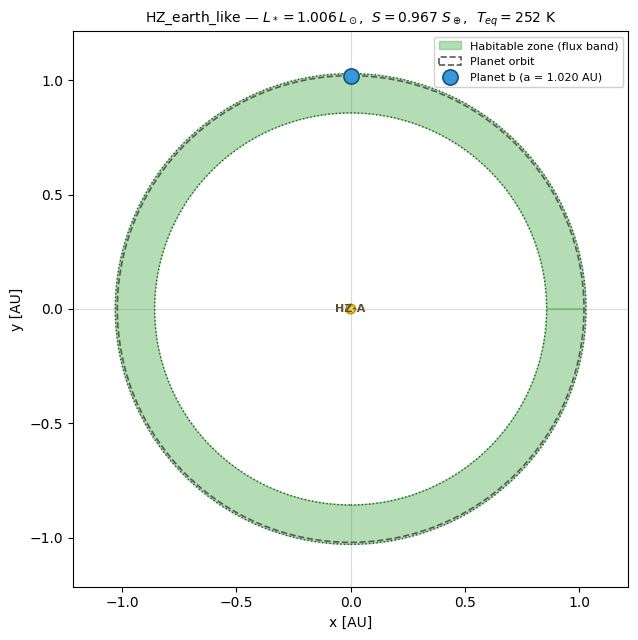

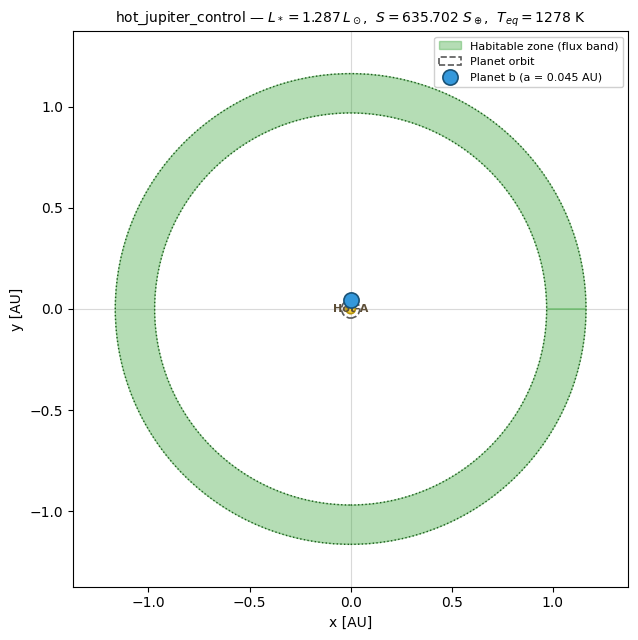

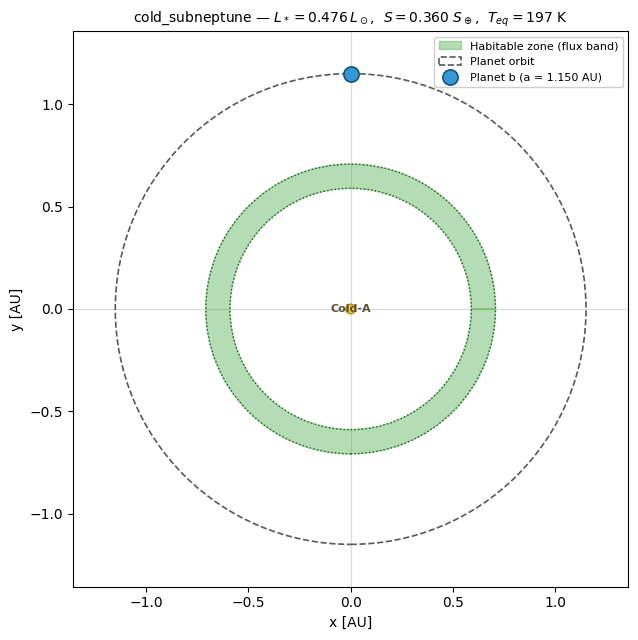

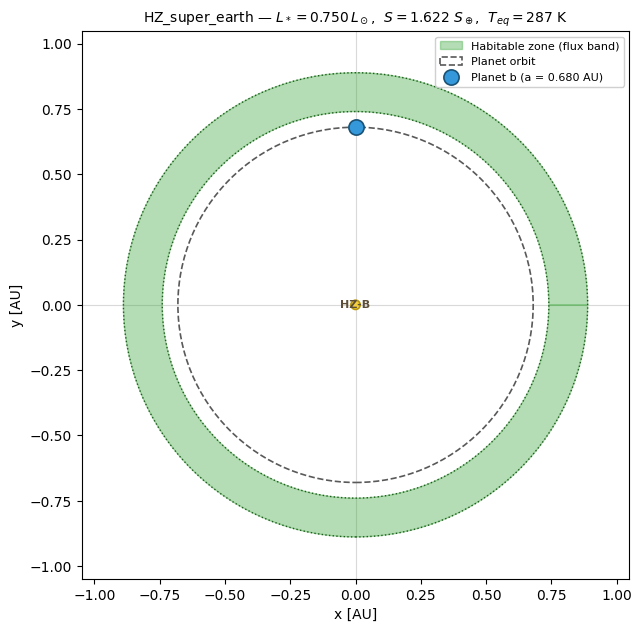

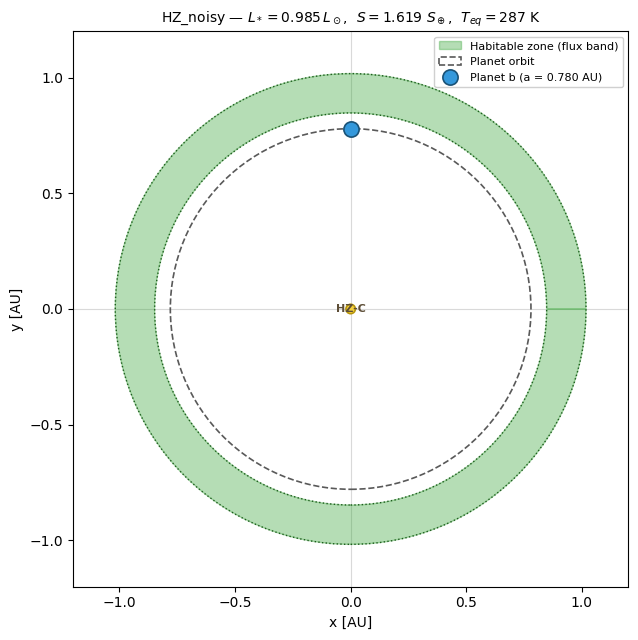

In [28]:
for i in range(len(systems)):
    plot = hz.plot_star_planet_system(systems[i], planet_index=0, planet_phase_deg= 90)
plt.show()